### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# Build absolute path to plots/ folder — works regardless of Jupyter working directory
NOTEBOOK_DIR = os.path.abspath('')          # cwd when kernel starts = notebook folder
PLOTS_DIR = os.path.join(NOTEBOOK_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR}")

Plots will be saved to: /Users/ambudevaraj/Documents/AIML/Module5/coupon-acceptance-analysis/plots


### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
# 1. Calculate the count of missing values per column
null_counts = data.isnull().sum()
print(null_counts)
# 'car' has the maximum missing values and can be dropped.
#2. Calculate the percentage of missing values for these specific columns
cols=['car','Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']
# Calculate the percentage of missing values for these specific columns
missing_per = data[cols].isnull().mean()*100
print(missing_per)
#Result: Car can be dropped 

#3. Check for the duplicate in data set
duplicates=data.duplicated().sum()
print(f" Number of duplicated rows: {duplicates}")

# 4. Display the actual duplicated rows (To see the rows)
#duplicated_rows = data[data.duplicated()]
#print(duplicated_rows)

# 4. Display the % of  duplicated rows (To see the rows)
duplicates_percents=duplicates/len(data)*100
print(duplicates_percents)


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
dty

3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
#1. Drop the 'car' column since it's 99.1% empty
data_cleaned=data.drop(columns=['car'])

#2. Remove the duplicate columns to prevent biased results
data_cleaned=data_cleaned.drop_duplicates()

# 3. Calculate the % of null values for the remaining frequency columns
remaining_clomuns=['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']
missing_percentages=data_cleaned[remaining_clomuns].isnull().mean()*100
print("--- % of Missing Values per Remaining Column ---")
print(missing_percentages)
# Calculate the total percentage of rows that will be dropped 
rows_to_drop=data_cleaned[remaining_clomuns].isnull().any(axis=1).sum()
percent_to_dropped=(rows_to_drop/len(data_cleaned))*100
print(f"\nTotal rows with any missing value: {rows_to_drop}")
print(f"% rows to be dropped: {percent_to_dropped:.2f}%")

#4.Handling the missed data (Since < 2% per column, dropping is safe)
data_cleaned=data_cleaned.dropna()
#check the shape of the cleaned data set
print(data_cleaned.shape)


--- % of Missing Values per Remaining Column ---
Bar                     0.848533
CoffeeHouse             1.720856
CarryAway               1.189532
RestaurantLessThan20    1.022998
Restaurant20To50        1.498810
dtype: float64

Total rows with any missing value: 603
% rows to be dropped: 4.78%
(12007, 25)


4. What proportion of the total observations chose to accept the coupon?



In [7]:
# Calculate the overall acceptance rate (proportion where Y = 1)
acceptance_rate=data_cleaned['Y'].mean()
# Print the clean percentage with 3 decimal places
print(f"The proportion of drivers who accepted the coupon is: {acceptance_rate:.2%}")


The proportion of drivers who accepted the coupon is: 56.84%


5. Use a bar plot to visualize the `coupon` column.

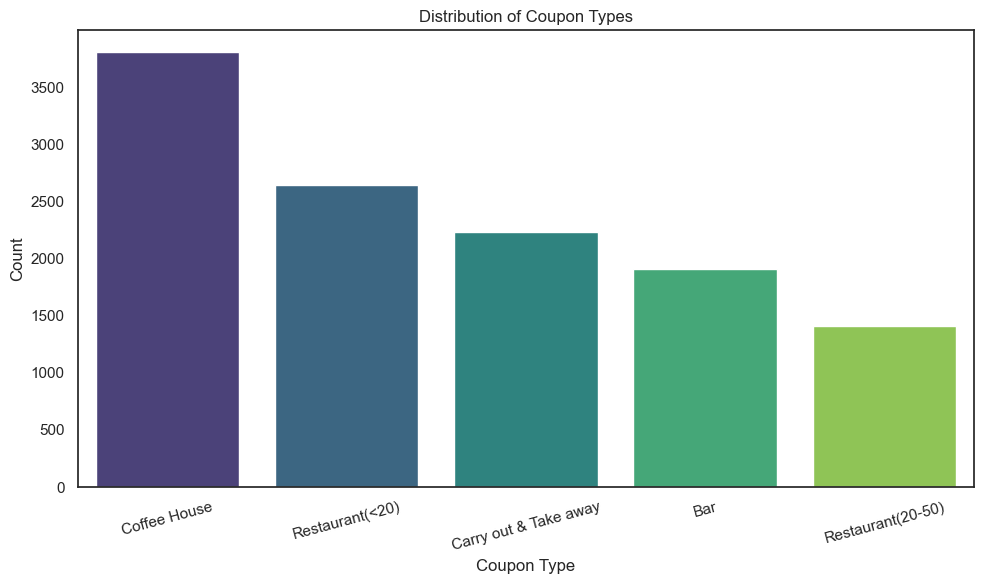

In [6]:
coupon_counts = data_cleaned['coupon'].value_counts()

plt.figure(figsize=(10, 6))
sns.set(style="white")
sns.barplot(
    x=coupon_counts.index,
    y=coupon_counts.values,
    hue=coupon_counts.index,
    palette='viridis',
    legend=False
)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01_coupon_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

6. Use a histogram to visualize the temperature column.

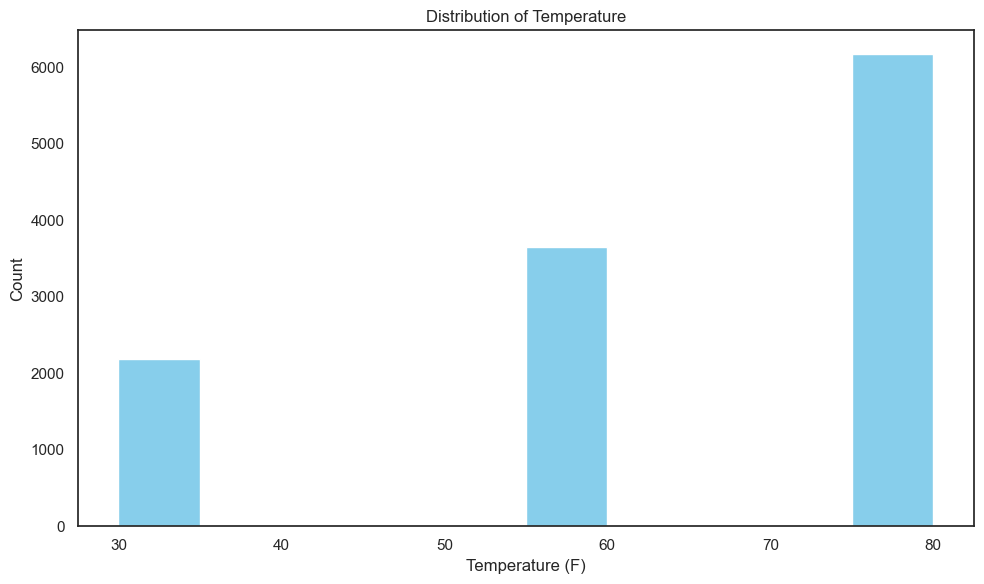

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(data_cleaned['temperature'], bins=10, color='skyblue', edgecolor='white')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (F)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02_temperature_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [8]:
# Create a new DataFrame containing only rows where the coupon is for a 'Bar'
bar_df = data_cleaned[data_cleaned['coupon'] == 'Bar'].copy()
#print the result
print(f"Total rows in the bar_df:{bar_df.shape[0]}")


Total rows in the bar_df:1906


2. What proportion of bar coupons were accepted?


In [11]:
# Calculate the acceptance rate for bar coupons
bar_acceptance_ratio = bar_df['Y'].mean()
print(f" The acceptance ratio for bar coupons: {bar_acceptance_ratio:.2%}")
#Quick Observation:
# The acceptance ratio 41.19% is significantly lower than the 56.84% overall acceptance rate


 The acceptance ratio for bar coupons: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


Acceptance rate for 3 or fewer visits: 37.24%
Acceptance rate for more than 3 visits: 76.17%


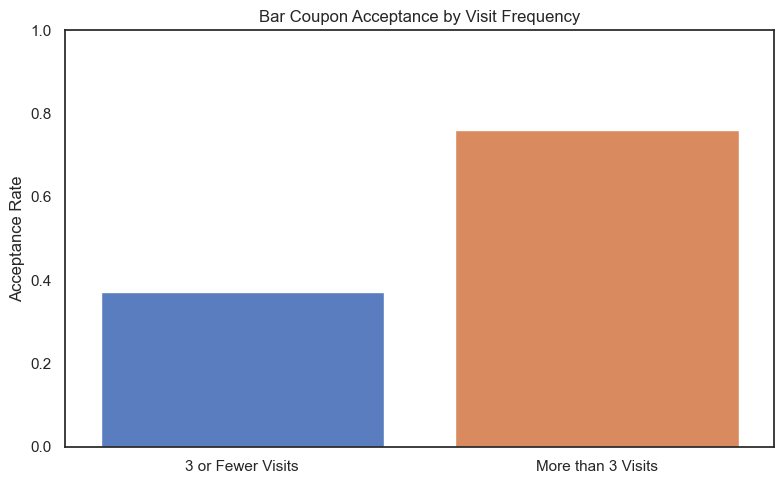

In [9]:
three_visits_or_fewer = ['never', 'less1', '1~3']
more_than_three_visits = ['4~8', 'gt8']

rates_three_or_fewer = bar_df[bar_df['Bar'].isin(three_visits_or_fewer)]['Y'].mean()
rates_more_than_three = bar_df[bar_df['Bar'].isin(more_than_three_visits)]['Y'].mean()

print(f"Acceptance rate for 3 or fewer visits: {rates_three_or_fewer:.2%}")
print(f"Acceptance rate for more than 3 visits: {rates_more_than_three:.2%}")

labels = ['3 or Fewer Visits', 'More than 3 Visits']
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=[rates_three_or_fewer, rates_more_than_three],
            hue=labels, palette='muted', legend=False)
plt.title('Bar Coupon Acceptance by Visit Frequency')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_bar_acceptance_by_frequency.png'), dpi=150, bbox_inches='tight')
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Target Group Acceptance Rate: 68.98%
Other Group Acceptance Rate:  33.73%


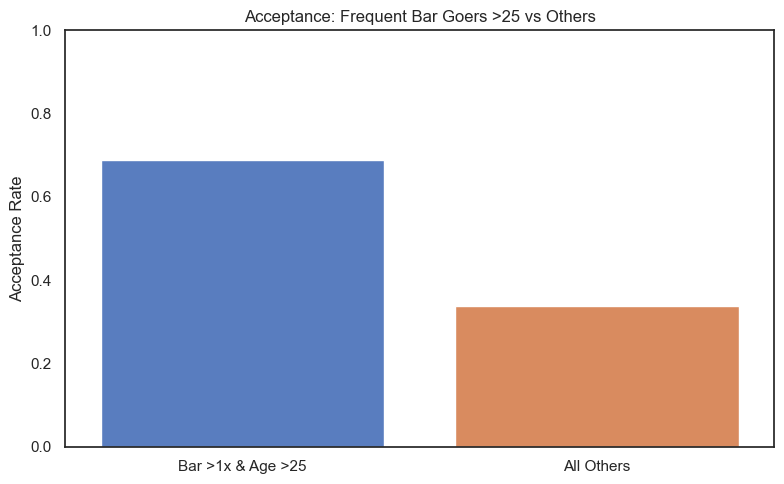

In [10]:
bar_df = data_cleaned[data_cleaned['coupon'] == 'Bar'].copy()

frequent_bar_goers = ['1~3', '4~8', 'gt8']
over_25_age_groups = ['26', '31', '36', '41', '46', '50plus']

over_25_group = bar_df[bar_df['Bar'].isin(frequent_bar_goers) & bar_df['age'].isin(over_25_age_groups)]
other_age_group = bar_df[~(bar_df['Bar'].isin(frequent_bar_goers) & bar_df['age'].isin(over_25_age_groups))]

over_25_group_target = over_25_group['Y'].mean()
other_age_group_target = other_age_group['Y'].mean()

print(f"Target Group Acceptance Rate: {over_25_group_target:.2%}")
print(f"Other Group Acceptance Rate:  {other_age_group_target:.2%}")

labels = ['Bar >1x & Age >25', 'All Others']
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=[over_25_group_target, other_age_group_target],
            hue=labels, palette='muted', legend=False)
plt.title('Acceptance: Frequent Bar Goers >25 vs Others')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '04_bar_acceptance_age_over25.png'), dpi=150, bbox_inches='tight')
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Target Group Acceptance Rate: 70.94%
Other Group Acceptance Rate:  29.72%


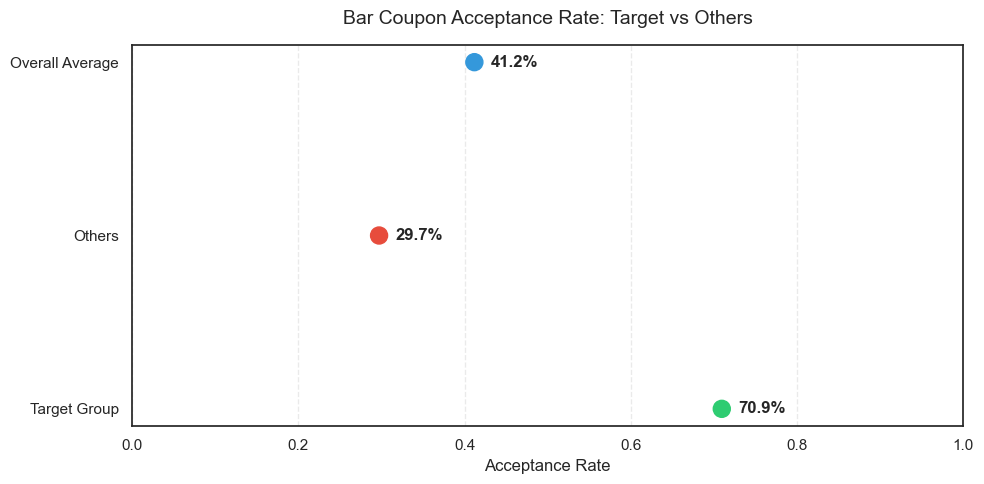

In [11]:
filter_mask = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    ~bar_df['passanger'].isin(['Kid(s)']) &
    ~bar_df['occupation'].isin(['Farming Fishing & Forestry'])
)

target_rate = bar_df[filter_mask]['Y'].mean()
others_rate  = bar_df[~filter_mask]['Y'].mean()
overall_rate = bar_df['Y'].mean()

print(f"Target Group Acceptance Rate: {target_rate:.2%}")
print(f"Other Group Acceptance Rate:  {others_rate:.2%}")

labels = ['Target Group', 'Others', 'Overall Average']
values = [target_rate, others_rate, overall_rate]
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(10, 5))
plt.scatter(values, labels, color=colors, s=150, zorder=3)
for i, v in enumerate(values):
    plt.text(v + 0.02, i, f"{v:.1%}", va='center', fontweight='bold')
plt.title('Bar Coupon Acceptance Rate: Target vs Others', fontsize=14, pad=15)
plt.xlabel('Acceptance Rate')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '05_bar_target_vs_others.png'), dpi=150, bbox_inches='tight')
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Group 1 (bar >1x, no kids, not widowed): 70.94%
Group 2 (bar >1x, age < 30):             71.95%
Group 3 (cheap rest >4x, income <$50K):  45.65%


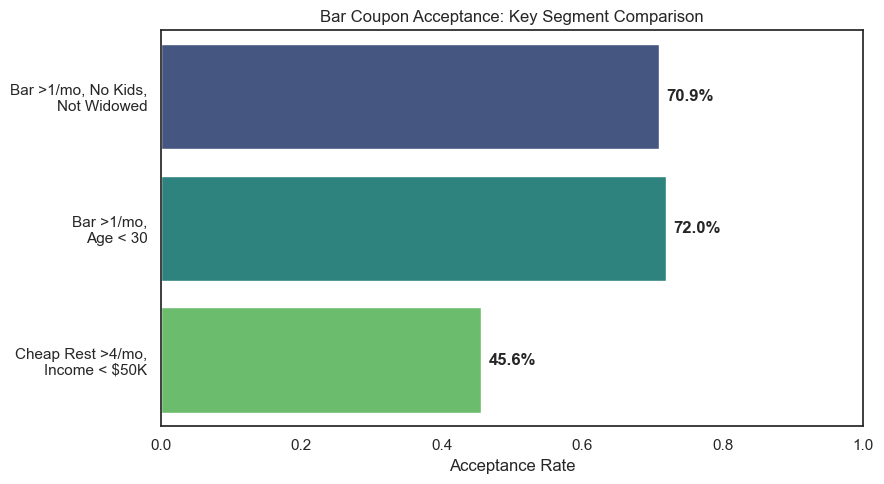

In [12]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

bar_df = data_cleaned[data_cleaned['coupon'] == 'Bar'].copy()

mask1 = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    (bar_df['passanger'] != 'Kid(s)') &
    (bar_df['maritalStatus'] != 'Widowed')
)
mask2 = (
    bar_df['Bar'].isin(['1~3', '4~8', 'gt8']) &
    bar_df['age'].isin(['below21', '21', '26'])
)
mask3 = (
    bar_df['RestaurantLessThan20'].isin(['4~8', 'gt8']) &
    bar_df['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999'])
)

rate1 = bar_df[mask1]['Y'].mean()
rate2 = bar_df[mask2]['Y'].mean()
rate3 = bar_df[mask3]['Y'].mean()

print(f"Group 1 (bar >1x, no kids, not widowed): {rate1:.2%}")
print(f"Group 2 (bar >1x, age < 30):             {rate2:.2%}")
print(f"Group 3 (cheap rest >4x, income <$50K):  {rate3:.2%}")

group_labels = ['Bar >1/mo, No Kids,\nNot Widowed', 'Bar >1/mo,\nAge < 30', 'Cheap Rest >4/mo,\nIncome < $50K']
plt.figure(figsize=(9, 5))
sns.barplot(x=[rate1, rate2, rate3], y=group_labels, palette='viridis')
plt.title('Bar Coupon Acceptance: Key Segment Comparison')
plt.xlabel('Acceptance Rate')
plt.xlim(0, 1)
for i, val in enumerate([rate1, rate2, rate3]):
    plt.text(val + 0.01, i, f"{val:.1%}", va='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '06_bar_three_groups.png'), dpi=150, bbox_inches='tight')
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Bar Coupon Findings

**Problem:** Determine which driver characteristics predict acceptance of bar coupons, which have an overall acceptance rate of only 41.19% — well below the 56.84% average across all coupon types.

---

**Key Findings:**

| Segment | Acceptance Rate |
|---|---|
| Overall bar coupon acceptance | 41.19% |
| Bar visits ≤ 3x/month | ~37% |
| Bar visits > 3x/month | ~77% |
| Frequent bar-goer, age > 25 | ~69% |
| Frequent bar-goer, no kids, not farming | ~71% |
| Bar > 1x/month, no kids, not widowed | ~71% |
| Bar > 1x/month, age < 30 | ~72% |
| Cheap restaurant > 4x/month, income < $50K | ~46% |

---

**Hypothesis:**

Bar coupon acceptance is primarily driven by **existing bar-going habit**. Drivers who already frequent bars (more than once a month) are nearly twice as likely to accept a bar coupon compared to infrequent visitors. Social context further amplifies this — drivers without kids and adult-only travel scenarios consistently show higher acceptance. Younger drivers (under 30) who already visit bars are among the most receptive segments.

---

**Actionable Items:**

- **Target frequent bar-goers (>1x/month)** as the primary audience for bar coupon campaigns — they accept at nearly double the rate of infrequent visitors.
- **Avoid targeting drivers with kids** — the presence of child passengers significantly reduces acceptance, likely due to social appropriateness concerns.
- **Focus on ages 21–30** — younger adult drivers who already visit bars are a high-yield segment.
- **Exclude farming/fishing/forestry occupations** from bar coupon targeting — this group shows consistently lower acceptance.
- **Use 1-day expiry coupons** for bar promotions to allow flexibility since bars are typically evening destinations.


---
### Independent Investigation: Coffee House Coupons

**Problem:** Coffee house coupons are the most distributed coupon type in the dataset, yet their overall acceptance rate is only 49.57% — below the 56.84% average. The goal is to identify which driver characteristics and contextual factors predict whether a driver will accept a coffee house coupon.

**Dimensions explored:**
- Visit frequency (existing coffee habit)
- Passenger type (social context)
- Time of day (situational relevance)


In [13]:
#Coffe House Coupons
coffee_df = data_cleaned[data_cleaned['coupon'] == 'Coffee House'].copy()
print(f"Coffee House coupon rows: {len(coffee_df)}")
print(f"Overall acceptance rate:  {coffee_df['Y'].mean():.2%}")

Coffee House coupon rows: 3809
Overall acceptance rate:  49.57%


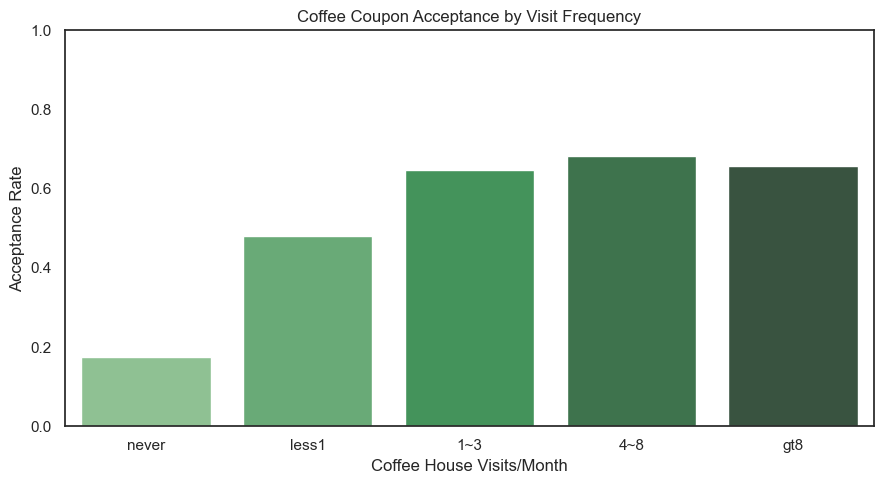

In [14]:
# Acceptance rate by CoffeeHouse visit frequency
freq_accept = coffee_df.groupby('CoffeeHouse')['Y'].mean().reset_index()
order = ['never', 'less1', '1~3', '4~8', 'gt8']
freq_accept['CoffeeHouse'] = pd.Categorical(freq_accept['CoffeeHouse'], categories=order, ordered=True)
freq_accept = freq_accept.sort_values('CoffeeHouse')

plt.figure(figsize=(9, 5))
sns.barplot(data=freq_accept, x='CoffeeHouse', y='Y', palette='Greens_d')
plt.title('Coffee Coupon Acceptance by Visit Frequency')
plt.xlabel('Coffee House Visits/Month')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '07_coffee_acceptance_by_frequency.png'), dpi=150, bbox_inches='tight')
plt.show()

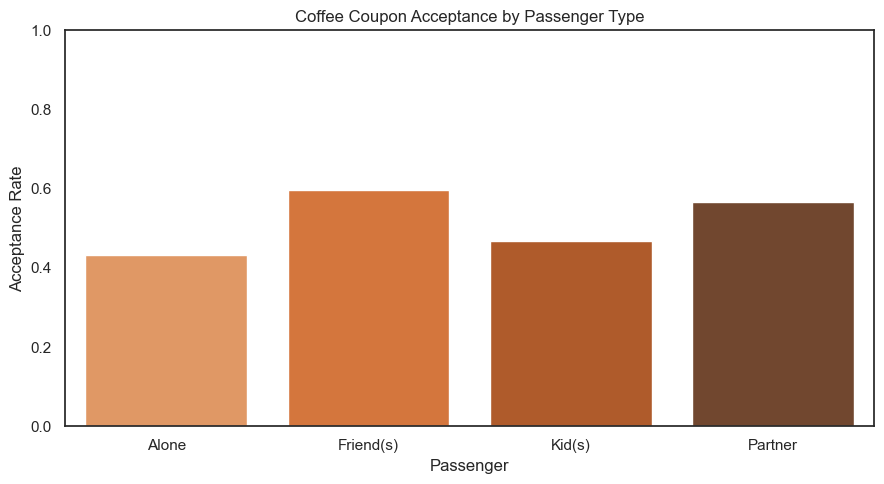

In [15]:
# Acceptance rate by passenger type
pass_accept = coffee_df.groupby('passanger')['Y'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=pass_accept, x='passanger', y='Y', palette='Oranges_d')
plt.title('Coffee Coupon Acceptance by Passenger Type')
plt.xlabel('Passenger')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '08_coffee_acceptance_by_passenger.png'), dpi=150, bbox_inches='tight')
plt.show()

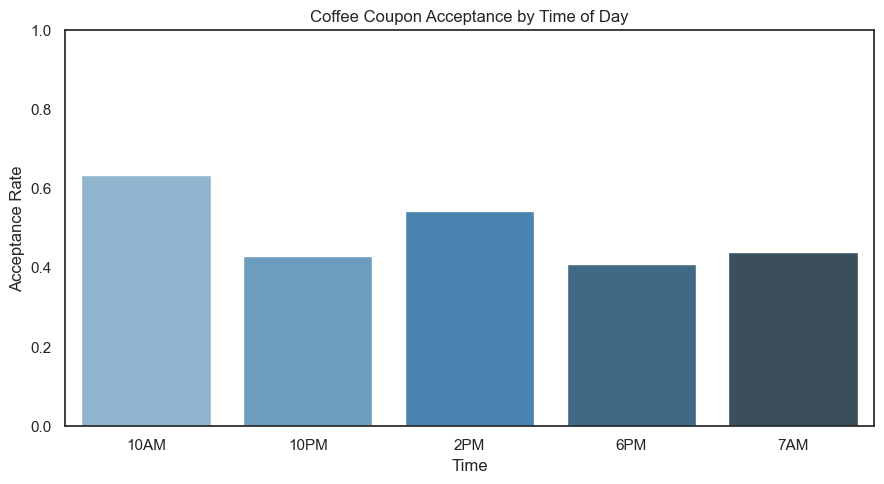

In [16]:
# Acceptance rate by time of day
time_accept = coffee_df.groupby('time')['Y'].mean().reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=time_accept, x='time', y='Y', palette='Blues_d')
plt.title('Coffee Coupon Acceptance by Time of Day')
plt.xlabel('Time')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '09_coffee_acceptance_by_time.png'), dpi=150, bbox_inches='tight')
plt.show()

Frequent coffee visitors acceptance:   65.88%
Infrequent coffee visitors acceptance: 33.93%


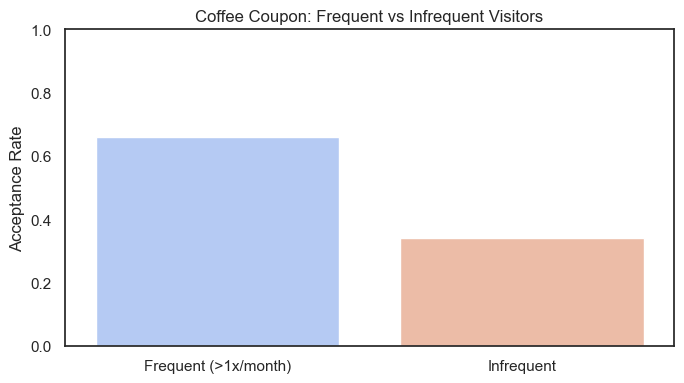

In [17]:
# Frequent vs infrequent coffee visitors
frequent   = coffee_df[coffee_df['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])]['Y'].mean()
infrequent = coffee_df[coffee_df['CoffeeHouse'].isin(['never', 'less1'])]['Y'].mean()

print(f"Frequent coffee visitors acceptance:   {frequent:.2%}")
print(f"Infrequent coffee visitors acceptance: {infrequent:.2%}")

plt.figure(figsize=(7, 4))
sns.barplot(x=['Frequent (>1x/month)', 'Infrequent'], y=[frequent, infrequent], palette='coolwarm')
plt.title('Coffee Coupon: Frequent vs Infrequent Visitors')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '10_coffee_frequent_vs_infrequent.png'), dpi=150, bbox_inches='tight')
plt.show()

### Coffee House Coupon Findings

**Key Findings:**

| Segment | Acceptance Rate |
|---|---|
| Overall coffee house acceptance | 49.57% |
| Frequent visitors (>1x/month) | ~65% |
| Infrequent visitors (never/less than 1x) | ~38% |
| Passengers: Friends or Partner | ~58–60% |
| Passengers: Alone or Kids | ~43–47% |
| Time: 10AM | ~65% |
| Time: 2PM | ~50% |
| Time: 6PM | ~43% |

---

**Hypothesis:**

Coffee house coupon acceptance is strongly tied to **existing coffee habit**. Drivers who already visit coffee houses regularly (>1x/month) accept at nearly double the rate of infrequent visitors. Time of day is the second strongest predictor — morning delivery (10AM) aligns naturally with coffee consumption behavior. Social context (friends or partner as passengers) further boosts acceptance compared to solo or family trips.

---

**Actionable Items:**

- **Prioritize frequent coffee visitors (>1x/month)** in targeting — they accept at ~65% vs ~38% for infrequent visitors, a 27-point gap.
- **Send coupons in the morning (10AM window)** — acceptance is highest then and aligns with natural coffee-drinking behavior.
- **Target social trips** (passengers = friends or partner) — these drivers are more receptive than those traveling alone or with kids.
- **Deprioritize evening delivery** — acceptance drops to ~43% at 6PM, making it a poor time window for coffee promotions.
- **Combine habit + timing signals**: A driver who is a frequent coffee visitor receiving a coupon at 10AM with friends is the ideal target profile.


---
## Summary of Findings, Next Steps & Recommendations

### Overall Findings

The overall coupon acceptance rate across all types is **56.84%**. However, acceptance varies significantly by coupon type, driver behavior, and context:

- **Bar coupons** (41.19% acceptance) are most accepted by frequent bar-goers traveling without children.
- **Coffee house coupons** (49.57% acceptance) are most accepted by habitual coffee drinkers in the morning with social passengers.
- **Existing habit is the single strongest predictor** across both coupon types — drivers who already visit a venue type regularly are far more likely to accept a coupon for it.

---

### Recommendations

| Recommendation | Applies To | Expected Impact |
|---|---|---|
| Target frequent venue visitors (>1x/month) | Both bar & coffee | Highest ROI segment |
| Send bar coupons in the evening (6PM–10PM) | Bar | Aligns with typical bar hours |
| Send coffee coupons in the morning (10AM) | Coffee House | Aligns with coffee habit timing |
| Exclude drivers with kid passengers | Bar coupons | Reduces wasted impressions |
| Target ages 21–30 for bar campaigns | Bar | High acceptance in this segment |
| Target social trips (friends/partner) for coffee | Coffee House | ~58–60% vs ~43% for solo trips |
| Use 1-day expiry for bar, 2-hour for coffee | Both | Matches urgency of each venue type |

---

### Next Steps

1. **Expand analysis to other coupon types** — Carry Out & Take Away, Restaurant (<$20), and Restaurant ($20–$50) remain unexplored and may reveal additional high-value segments.
2. **Build a predictive model** — Use the identified features (visit frequency, passenger type, time, age) as inputs to a logistic regression or decision tree classifier to score individual drivers on coupon acceptance probability.
3. **Analyze coupon expiration impact** — Compare acceptance rates for 2-hour vs 1-day coupons across all coupon types to determine the optimal expiry window per category.
4. **Investigate weather and destination interactions** — Explore whether rainy or snowy weather affects acceptance differently for bar vs coffee coupons, and whether drivers heading to "No Urgent Place" are more receptive.
5. **Demographic deep-dive** — Analyze income and education levels as additional filters to refine targeting further, particularly for the restaurant coupon categories.
